Data loaded successfully!

----- Model Comparison Results -----
Logistic Regression: 0.8921
XGBoost: 0.8956


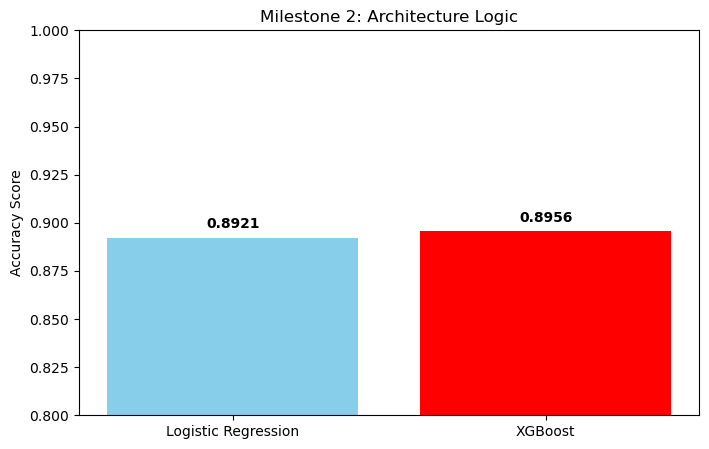

In [9]:
# Milestone 2 : Compare Logistic Regression and XGBoost
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score

# 1. Load the data from Milestone 1
X_train = np.load('X_train.npy')
X_val = np.load('X_val.npy')
y_train = np.load('y_train.npy')
y_val = np.load('y_val.npy')

print("Data loaded successfully!")

# 2. Train Logistic Regression 
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)
lr_acc = accuracy_score(y_val, lr.predict(X_val))

# 3. Train XGBoost 
# removed the unused 'use_label_encoder' parameter
xgb = XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=5, random_state=42, eval_metric='logloss')
xgb.fit(X_train, y_train)
xgb_acc = accuracy_score(y_val, xgb.predict(X_val))

# 4. Results Comparison
print(f"\n----- Model Comparison Results -----")
print(f"Logistic Regression: {lr_acc:.4f}")
print(f"XGBoost: {xgb_acc:.4f}")

# 5. Visualizing the Decision
models = ['Logistic Regression', 'XGBoost']
accuracies = [lr_acc, xgb_acc]

plt.figure(figsize=(8, 5))
plt.bar(models, accuracies, color=['skyblue', 'red'])
plt.ylabel('Accuracy Score')
plt.title('Milestone 2: Architecture Logic')
plt.ylim(0.8, 1.0) 
for i, v in enumerate(accuracies):
    plt.text(i, v + 0.005, f"{v:.4f}", ha='center', fontweight='bold')
plt.show()